In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.metrics import silhouette_score

In [15]:
csv_url = "https://drive.google.com/file/d/1CoIbh-cWOMOpbPWwEOzr2hwM7y7fdDG3/view?usp=sharing"
csv_url = 'https://drive.google.com/uc?id=' + csv_url.split('/')[-2]

df = pd.read_csv(csv_url)
df.head()


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,-9.12520,124.66084,336.43,0.38,0.36,2024-01-01,512,N,VIIRS,n,2,302.21,3.61,D,0
1,-9.54513,120.05059,331.87,0.55,0.43,2024-01-01,513,N,VIIRS,n,2,298.26,2.67,D,0
2,-8.27245,123.50804,348.94,0.39,0.36,2024-01-01,513,N,VIIRS,n,2,307.75,10.97,D,1
3,-5.17522,123.01190,335.65,0.39,0.36,2024-01-01,514,N,VIIRS,n,2,299.92,4.15,D,0
4,-4.92454,120.19463,336.39,0.48,0.40,2024-01-01,514,N,VIIRS,n,2,298.14,27.74,D,0


In [16]:
df['acq_date'] = pd.to_datetime(df['acq_date'])
df = df[(df['acq_date'].dt.year >= 2015) & (df['acq_date'].dt.year <= 2025)]

# Bounding Box koordinat kasar untuk area Sulawesi & Maluku
# Latitude (Lintang): -8.5 sampai 3.0
# Longitude (Bujur): 118.0 sampai 135.0
kondisi_wilayah = (
    (df['latitude'] >= -8.5) & (df['latitude'] <= 3.0) &
    (df['longitude'] >= 118.0) & (df['longitude'] <= 135.0)
)
df_filtered = df[kondisi_wilayah].copy()

print(f"Jumlah data titik api setelah difilter (Sulawesi & Maluku): {len(df_filtered)}")

X = df_filtered[['longitude', 'latitude']]

Jumlah data titik api setelah difilter (Sulawesi & Maluku): 18873


In [17]:
#Metode Elbow
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

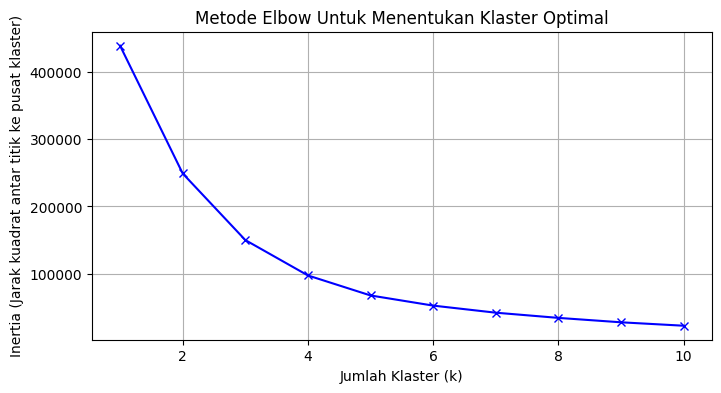

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('Inertia (Jarak kuadrat antar titik ke pusat klaster)')
plt.title('Metode Elbow Untuk Menentukan Klaster Optimal')
plt.grid(True)
plt.show()

In [19]:
k_optimal = 4

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_filtered['cluster'] = kmeans.fit_predict(X)


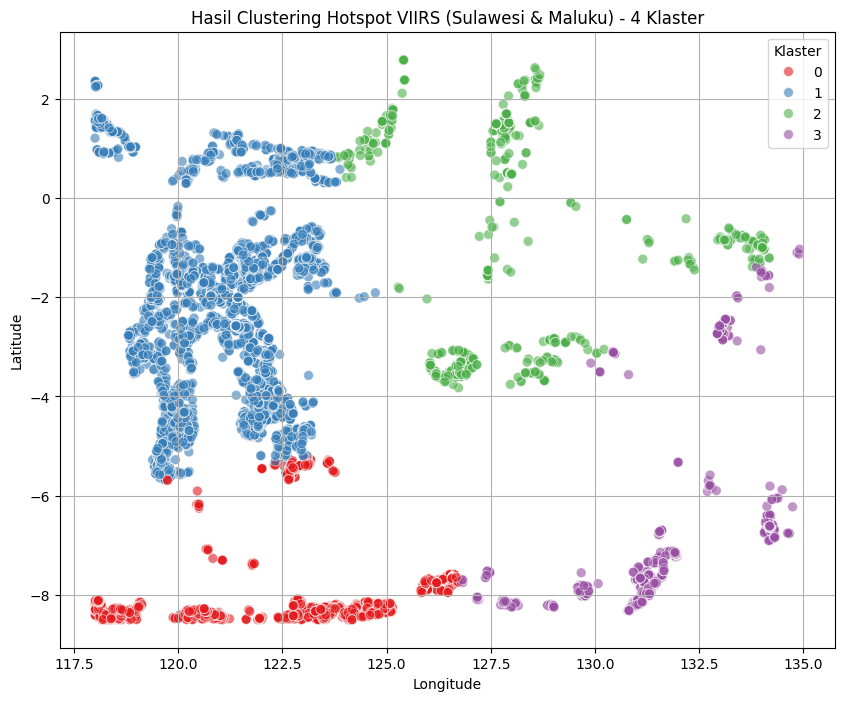

In [20]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='longitude',
    y='latitude',
    hue='cluster',
    data=df_filtered,
    palette='Set1',
    s=50,
    alpha=0.6
)
plt.title(f'Hasil Clustering Hotspot VIIRS (Sulawesi & Maluku) - {k_optimal} Klaster')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Klaster')
plt.grid(True)
plt.show()

In [22]:
score = silhouette_score(X, df_filtered['cluster'])
print(f"Silhouette Score untuk {k_optimal} klaster: {score:.3f}")

Silhouette Score untuk 4 klaster: 0.573


In [24]:
df_filtered.to_csv('Hasil_Clustering_VIIRS_SulMal.csv', index=False)
print("Data berhasil disimpan!")

Data berhasil disimpan!
